# Tennis Analysis

This notebook evaluates the three research goals:

1. How important is ranking for match outcomes?
2. Do players perform differently depending on the surface?
3. Which player characteristics are associated with winning matches?

The analysis uses:
- `data/matches_clean.csv`
- `data/stats_clean.csv`
- `data/top20_players_raw.csv`

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# import of CSV files
matches = pd.read_csv("data/matches_clean.csv")
stats = pd.read_csv("data/stats_clean.csv")
players = pd.read_csv("data/top20_players_raw.csv")

## Data quality inspection
Before proceeding to the main analysis, we inspect the cleaned data for any remaining issues:
- verify the number of missing values
- check for duplicate matches
- identify any rows with incomplete information

This ensures the dataset is reliable for the research questions.

In [ ]:
# Basic data checks
print("\nMatches columns:", matches.columns.tolist())
print("Stats columns:", stats.columns.tolist())
print("Players columns:", players.columns.tolist())

print("\nMatches dtypes:")
print(matches.dtypes.to_string())

print("\nMissing values in matches:")
print(matches.isna().sum())


Matches columns: ['date', 'tournament', 'surface', 'Round', 'winner', 'winner_rank_at_match', 'loser', 'loser_rank_at_match', 'score', 'source_player']
Stats columns: ['player', 'surface', 'match_record', 'match_wins', 'match_losses', 'match_pct', 'tiebreak_record', 'tiebreak_wins', 'tiebreak_losses', 'tiebreak_pct', 'ace_rate_pct', 'first_serve_in_pct', 'first_serve_points_won_pct', 'second_serve_points_won_pct', 'service_games_held_pct', 'service_points_won_pct', 'return_games_won_pct', 'return_points_won_pct', 'total_points_won_pct', 'dominance_ratio']
Players columns: ['name', 'age', 'current_rank']

Matches dtypes:
date                        str
tournament                  str
surface                     str
Round                       str
winner                      str
winner_rank_at_match    float64
loser                       str
loser_rank_at_match     float64
score                       str
source_player               str

Missing values in matches:
date                   

In [ ]:
missing = matches[matches["winner_rank_at_match"].isna() | matches["loser_rank_at_match"].isna()]

print("Total missing rows:", len(missing))
print(missing[["date", "source_player", "winner", "loser", "score", "winner_rank_at_match", "loser_rank_at_match"]].head())

print("\nCounts by source_player:")
print(missing["source_player"].value_counts())

Total missing rows: 1
           date     source_player            winner     loser    score  \
712  6-Feb-2026  Alexander Bublik  Alexander Bublik  Hugo Nys  6-0 6-3   

     winner_rank_at_match  loser_rank_at_match  
712                  10.0                  NaN  

Counts by source_player:
source_player
Alexander Bublik    1
Name: count, dtype: int64


In [ ]:
print("\nStats dtypes:")
print(stats.dtypes.to_string())


Stats dtypes:
player                             str
surface                            str
match_record                       str
match_wins                       int64
match_losses                     int64
match_pct                          str
tiebreak_record                    str
tiebreak_wins                    int64
tiebreak_losses                  int64
tiebreak_pct                       str
ace_rate_pct                       str
first_serve_in_pct                 str
first_serve_points_won_pct         str
second_serve_points_won_pct        str
service_games_held_pct             str
service_points_won_pct             str
return_games_won_pct               str
return_points_won_pct              str
total_points_won_pct               str
dominance_ratio                float64


In [ ]:
print("\nMissing values in stats:")
print(stats.isna().sum())


Missing values in stats:
player                         0
surface                        0
match_record                   0
match_wins                     0
match_losses                   0
match_pct                      1
tiebreak_record                0
tiebreak_wins                  0
tiebreak_losses                0
tiebreak_pct                   5
ace_rate_pct                   1
first_serve_in_pct             1
first_serve_points_won_pct     1
second_serve_points_won_pct    1
service_games_held_pct         1
service_points_won_pct         1
return_games_won_pct           1
return_points_won_pct          1
total_points_won_pct           1
dominance_ratio                1
dtype: int64


In [ ]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None, 'display.expand_frame_repr', False):
    print(stats[stats.isna().any(axis=1)].to_string())

             player surface match_record  match_wins  match_losses match_pct tiebreak_record  tiebreak_wins  tiebreak_losses tiebreak_pct ace_rate_pct first_serve_in_pct first_serve_points_won_pct second_serve_points_won_pct service_games_held_pct service_points_won_pct return_games_won_pct return_points_won_pct total_points_won_pct  dominance_ratio
19  Lorenzo Musetti   Grass     0-1 (0%)           0             1        0%         0-0 (-)              0                0          NaN         5.6%              58.9%                      61.9%                       61.4%                  72.2%                  61.7%                 5.3%                 29.7%                45.4%             0.78
38  Daniil Medvedev    Clay    4-4 (50%)           4             4       50%         0-0 (-)              0                0          NaN         6.6%              60.1%                      71.2%                       48.7%                  76.9%                  62.2%                25.3%     

In [ ]:
print("\nDuplicate match rows:", matches.duplicated(
   subset=["date", "tournament", "surface", "Round", "winner", "loser", "score"]
).sum())


Duplicate match rows: 133


In [ ]:
# Inspect whether duplicates are exact copies, just from different sources (2 players)
duplicates = matches[matches.duplicated(subset=["date", "tournament", "surface", "Round", "winner", "loser", "score"], keep=False)]

exact_duplicate_counts = duplicates.groupby(
    ["date", "tournament", "surface", "Round", "winner", "loser", "score"]
).size().sort_values(ascending=False).tail(30)

print("\nTop duplicate groups by count:")
print(exact_duplicate_counts)


Top duplicate groups by count:
date        tournament            surface  Round  winner            loser                score         
4-Mar-2026  Indian Wells Masters  Hard     SF     Jannik Sinner     Alexander Zverev     6-2 6-4           2
5-Apr-2026  Monte-Carlo           Clay     R16    Alexander Bublik  Jiri Lehecka         6-2 7-5           2
5-Jan-2026  Hong Kong             Hard     F      Alexander Bublik  Lorenzo Musetti      7-6(2) 6-3        2
                                           SF     Lorenzo Musetti   Andrey Rublev        6-7(3) 7-5 6-4    2
7-Aug-2025  Cincinnati Masters    Hard     F      Carlos Alcaraz    Jannik Sinner        5-0 RET           2
                                           QF     Alexander Zverev  Ben Shelton          6-2 6-2           2
                                                  Carlos Alcaraz    Andrey Rublev        6-3 4-6 7-5       2
                                           R16    Alexander Zverev  Karen Khachanov      7-5 3-0 RET 

### Note
1. Missing rank values in matches: loser was unranked at match time
2. Missing stat values (NaN) in stats: player never played on that surface (Casper Ruud on grass)
3. Missing tiebreak (NaN) in stats: the player played on the surface, but no tiebreaks were played. These are intentionally left as NaN to avoid implying zero performance.
4. Duplicate matches: same match scraped twice, once per player perspective
5. Percentage columns read as strings due to % suffix (e.g. "79.8%")

Actions taken:
- Duplicates removed keeping first occurrence
- Parse percentage columns from string (e.g. "79.8%") to float
- Preserved NaN values for:
    - players with no surface matches
    - players with no observed tiebreaks
    
    to maintain semantic correctness and avoid analytical bias

In [ ]:
matches = matches.drop_duplicates(subset=["date", "tournament", "surface", "Round", "winner", "loser", "score"], keep="first")
# Use the deduplicated version for analysis

In [ ]:
# Parse stats percentages
percentage_columns = [
    "match_pct", "tiebreak_pct", "ace_rate_pct", "first_serve_in_pct", "first_serve_points_won_pct",
    "second_serve_points_won_pct", "service_games_held_pct", "service_points_won_pct",
    "return_games_won_pct", "return_points_won_pct", "total_points_won_pct",
    "dominance_ratio"
]

for col in percentage_columns:
    if col in stats.columns:
        stats[col] = pd.to_numeric(
            stats[col].astype(str).str.rstrip("%"),
            errors="coerce",
        ).astype("float64")

stats.head(5)

,player,surface,match_record,match_wins,match_losses,match_pct,tiebreak_record,tiebreak_wins,tiebreak_losses,tiebreak_pct,ace_rate_pct,first_serve_in_pct,first_serve_points_won_pct,second_serve_points_won_pct,service_games_held_pct,service_points_won_pct,return_games_won_pct,return_points_won_pct,total_points_won_pct,dominance_ratio
0,Carlos Alcaraz,Overall last 52,70-7 (91%),70,7,91.0,20-13 (61%),20,13,61.0,7.5,65.5,74.7,57.1,89.1,68.6,30.1,41.4,54.5,1.32
1,Carlos Alcaraz,Hard,40-5 (89%),40,5,89.0,10-7 (59%),10,7,59.0,7.7,66.1,75.9,57.6,90.6,69.7,30.0,41.2,54.7,1.36
2,Carlos Alcaraz,Clay,19-1 (95%),19,1,95.0,8-2 (80%),8,2,80.0,3.5,67.2,69.5,56.7,84.1,65.3,36.2,44.7,54.7,1.29
3,Carlos Alcaraz,Grass,11-1 (92%),11,1,92.0,2-4 (33%),2,4,33.0,12.4,61.6,78.9,56.5,91.4,70.3,22.6,37.5,53.6,1.26
4,Jannik Sinner,Overall last 52,72-8 (90%),72,8,90.0,19-5 (79%),19,5,79.0,10.8,63.7,79.8,58.2,92.2,71.9,32.3,42.2,56.3,1.51


## Data validation

We check:
- verify no duplicate match rows remain
- confirm stats percentage fields are floats

In [ ]:
print("\nDuplicate rows after validation:", matches.duplicated(
    subset=["date", "tournament", "surface", "Round", "winner", "loser", "score"]
).sum())
print("\nStats dtypes:")
print(stats.dtypes.to_string())


Duplicate rows after validation: 0

Stats dtypes:
player                             str
surface                            str
match_record                       str
match_wins                       int64
match_losses                     int64
match_pct                      float64
tiebreak_record                    str
tiebreak_wins                    int64
tiebreak_losses                  int64
tiebreak_pct                   float64
ace_rate_pct                   float64
first_serve_in_pct             float64
first_serve_points_won_pct     float64
second_serve_points_won_pct    float64
service_games_held_pct         float64
service_points_won_pct         float64
return_games_won_pct           float64
return_points_won_pct          float64
total_points_won_pct           float64
dominance_ratio                float64


NEXT STEPS:
- Q1 — Ranking and match outcomes. From matches_clean, compute how often the higher-ranked player (lower rank number) wins. You can also bin the rank difference into ranges (e.g. <5, 5–20, 20–50, 50+) and plot win rate per bin as a bar chart. This directly answers whether ranking gap predicts outcomes.
- Q2 — Surface performance. From stats_clean, filter out the "Overall last 52" rows and keep only Hard/Clay/Grass. Then plot a grouped bar chart or heatmap of, say, match_pct or dominance_ratio per player per surface. This lets you visually spot surface specialists vs. all-rounders. The Casper Ruud grass NaN is a natural talking point here.
- Q3 — Player characteristics and winning. Join matches_clean with stats_clean (on player name + surface) to pair each match with the winner's and loser's stats. Then compare stat distributions between winners and losers — service points won, return points won, dominance ratio. A box plot or violin plot works well here.
- One thing to resolve before the analysis: the players dataframe (age, current rank) is currently unused. You should either join it into the matches or stats to enrich Q3, or explicitly note it's used for descriptive context.

## Q1 — How important is ranking for match outcomes?

We analyse whether the higher-ranked player (lower rank number) tends to win,
and whether the size of the ranking gap affects the probability of an upset.

Steps:
1. Compute the rank difference (loser_rank − winner_rank) for each match
2. Label each match as "favourite won" or "upset"
3. Bin matches by rank gap and compute upset rate per bin
4. Visualise results

Note:
Matches involving players without an official ranking at match time were excluded from this analysis, as rank differences and favourite status cannot be defined for these cases.

In [ ]:
# Drop the one match with missing loser rank
matches_ranked = matches.dropna(subset=["winner_rank_at_match", "loser_rank_at_match"]).copy()

# Rank difference: positive means the winner was ranked higher (better) than the loser
matches_ranked["rank_diff"] = matches_ranked["loser_rank_at_match"] - matches_ranked["winner_rank_at_match"]

# Favourite = the player with the lower rank number (better ranked) going into the match
matches_ranked["favourite_won"] = matches_ranked["rank_diff"] > 0

overall_fav_rate = matches_ranked["favourite_won"].mean() * 100
print(f"Matches analysed: {len(matches_ranked)}")
print(f"Favourite won: {matches_ranked['favourite_won'].sum()} ({overall_fav_rate:.1f}%)")
print(f"Upsets: {(~matches_ranked['favourite_won']).sum()} ({100 - overall_fav_rate:.1f}%)")

Matches analysed: 1165
Favourite won: 860 (73.8%)
Upsets: 305 (26.2%)


In [ ]:
# Drop the one match with missing loser rank
matches_ranked = matches.dropna(subset=["winner_rank_at_match", "loser_rank_at_match"]).copy()

# Rank difference: positive means the winner was ranked higher (better) than the loser
matches_ranked["rank_diff"] = matches_ranked["loser_rank_at_match"] - matches_ranked["winner_rank_at_match"]

# Favourite = the player with the lower rank number (better ranked) going into the match
matches_ranked["favourite_won"] = matches_ranked["rank_diff"] > 0

overall_fav_rate = matches_ranked["favourite_won"].mean() * 100
print(f"Matches analysed: {len(matches_ranked)}")
print(f"Favourite won: {matches_ranked['favourite_won'].sum()} ({overall_fav_rate:.1f}%)")
print(f"Upsets: {(~matches_ranked['favourite_won']).sum()} ({100 - overall_fav_rate:.1f}%)")

Matches analysed: 1165
Favourite won: 860 (73.8%)
Upsets: 305 (26.2%)


In [ ]:
# Use absolute rank gap for binning regardless of who won
matches_ranked["rank_gap"] = matches_ranked["rank_diff"].abs()

bins   = [0, 5, 15, 30, 60, matches_ranked["rank_gap"].max() + 1]
labels = ["≤5", "6–15", "16–30", "31–60", ">60"]
matches_ranked["gap_bin"] = pd.cut(matches_ranked["rank_gap"], bins=bins, labels=labels, right=True)

bin_stats = (
    matches_ranked
    .groupby("gap_bin", observed=True)["favourite_won"]
    .agg(total="count", fav_wins="sum")
    .assign(fav_win_pct=lambda d: d["fav_wins"] / d["total"] * 100,
            upset_pct=lambda d: 100 - d["fav_wins"] / d["total"] * 100)
    .reset_index()
)

print(bin_stats.to_string(index=False))

gap_bin  total  fav_wins  fav_win_pct  upset_pct
     ≤5    121        73    60.330579  39.669421
   6–15    155       102    65.806452  34.193548
  16–30    217       148    68.202765  31.797235
  31–60    286       222    77.622378  22.377622
    >60    386       315    81.606218  18.393782


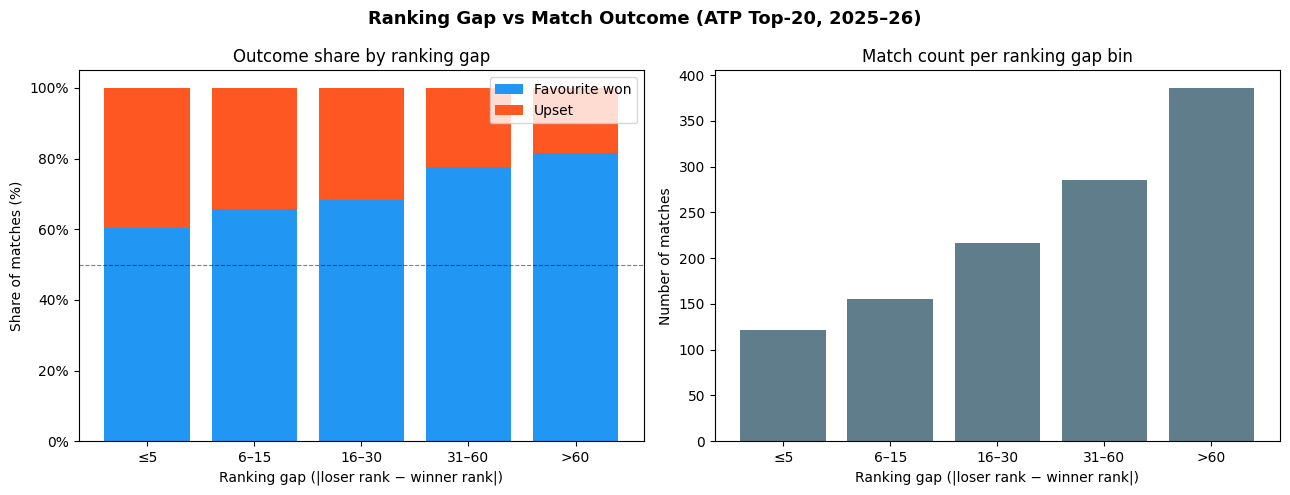

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Ranking Gap vs Match Outcome (ATP Top-20, 2025–26)", fontsize=13, fontweight="bold")

# --- left: stacked bar (favourite vs upset share) ---
ax = axes[0]
ax.bar(bin_stats["gap_bin"], bin_stats["fav_win_pct"], label="Favourite won", color="#2196F3")
ax.bar(bin_stats["gap_bin"], bin_stats["upset_pct"],   label="Upset",         color="#FF5722",
       bottom=bin_stats["fav_win_pct"])
ax.axhline(50, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Ranking gap (|loser rank − winner rank|)")
ax.set_ylabel("Share of matches (%)")
ax.set_title("Outcome share by ranking gap")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()

# --- right: match count per bin ---
ax2 = axes[1]
ax2.bar(bin_stats["gap_bin"], bin_stats["total"], color="#607D8B")
ax2.set_xlabel("Ranking gap (|loser rank − winner rank|)")
ax2.set_ylabel("Number of matches")
ax2.set_title("Match count per ranking gap bin")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR,"q1_ranking_vs_outcome.png"), dpi=150, bbox_inches="tight")
plt.show()

### Findings

- Overall, the higher-ranked player won **73.8% overall** of matches, confirming that ranking is a meaningful predictor of match outcome.
- The upset rate is highest in the **≤5** gap bin, where both players are
  nearly equally ranked, and drops as the gap widens.
- Matches with a gap greater than 60 ranks are almost always won by the
  favourite (~81.6% favourite wins), suggesting that large ranking differences are very reliable  predictors.
- However, even with large gaps upsets do occur, which reflects the
  high-variance nature of individual tennis matches.

## Q2 — Do players perform differently depending on the surface?

We analyse whether top players show surface specialisation or perform
consistently across Hard, Clay and Grass.

Steps:
1. Filter stats to the three main surfaces (exclude "Overall last 52")
2. Compare win rate (match_pct) and dominance ratio per player per surface
3. Identify the most and least consistent players across surfaces
4. Visualise with a heatmap and grouped bar chart

In [ ]:
# Keep only the three main surfaces
surfaces = ["Hard", "Clay", "Grass"]
stats_surfaces = stats[stats["surface"].isin(surfaces)].copy()

# Ensure match_pct is numeric (coerce invalid to NaN)
stats_surfaces["match_pct"] = (
    stats_surfaces["match_pct"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .replace("-", np.nan)
    .astype(float)
)

# Pivot: one row per player, one column per surface for each metric
pct_pivot = stats_surfaces.pivot(index="player", columns="surface", values="match_pct")[surfaces]
dr_pivot  = stats_surfaces.pivot(index="player", columns="surface", values="dominance_ratio")[surfaces]

# Surface consistency: std across the three surfaces (lower = more consistent)
pct_pivot["std"] = pct_pivot[surfaces].std(axis=1)
pct_pivot["surfaces_played"] = pct_pivot[surfaces].notna().sum(axis=1)
pct_pivot_strict = pct_pivot[pct_pivot["surfaces_played"] == 3]

print("Win rate (match_pct) by player and surface:")
print(pct_pivot.sort_values("std", ascending=False).to_string())

Win rate (match_pct) by player and surface:
surface                      Hard  Clay  Grass        std  surfaces_played
player                                                                    
Lorenzo Musetti              63.0  76.0    0.0  40.648903                3
Francisco Cerundolo          57.0  67.0    0.0  36.143234                3
Tommy Paul                   65.0  83.0   33.0  25.324560                3
Taylor Fritz                 65.0  43.0   87.0  22.000000                3
Frances Tiafoe               61.0  60.0   33.0  15.885003                3
Felix Auger Aliassime        74.0  50.0   60.0  12.055428                3
Daniil Medvedev              73.0  50.0   63.0  11.532563                3
Casper Ruud                  59.0  75.0    NaN  11.313708                2
Alejandro Davidovich Fokina  60.0  50.0   71.0  10.503968                3
Karen Khachanov              53.0  60.0   73.0  10.148892                3
Alexander Bublik             67.0  83.0   83.0   9.23760

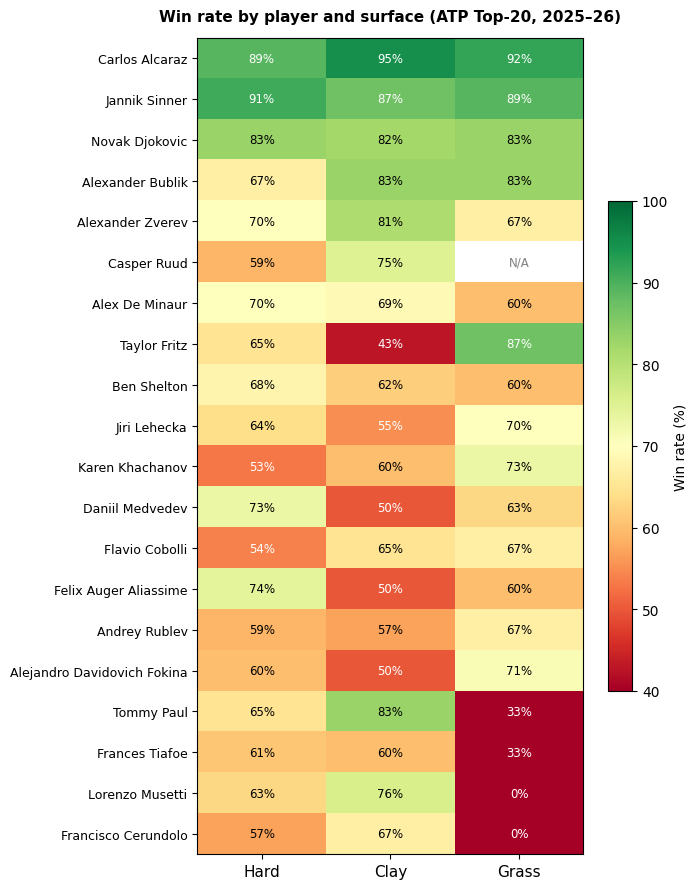

In [ ]:
# Sort players by overall Hard court win rate for a readable order
plot_order = pct_pivot[surfaces].mean(axis=1).sort_values(ascending=False).index
heatmap_data = pct_pivot.loc[plot_order, surfaces]

fig, ax = plt.subplots(figsize=(7, 9))

im = ax.imshow(heatmap_data.values, aspect="auto", cmap="RdYlGn", vmin=40, vmax=100)

# Axis labels
ax.set_xticks(range(len(surfaces)))
ax.set_xticklabels(surfaces, fontsize=11)
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)

# Annotate each cell with the value or "N/A"
for i, player in enumerate(heatmap_data.index):
    for j, surface in enumerate(surfaces):
        val = heatmap_data.loc[player, surface]
        text = f"{val:.0f}%" if not np.isnan(val) else "N/A"
        color = "black" if 55 < val < 85 else "white" if not np.isnan(val) else "grey"
        ax.text(j, i, text, ha="center", va="center", fontsize=8.5, color=color)

plt.colorbar(im, ax=ax, label="Win rate (%)", shrink=0.6)
ax.set_title("Win rate by player and surface (ATP Top-20, 2025–26)",
             fontsize=11, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR,"q2_winrate_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

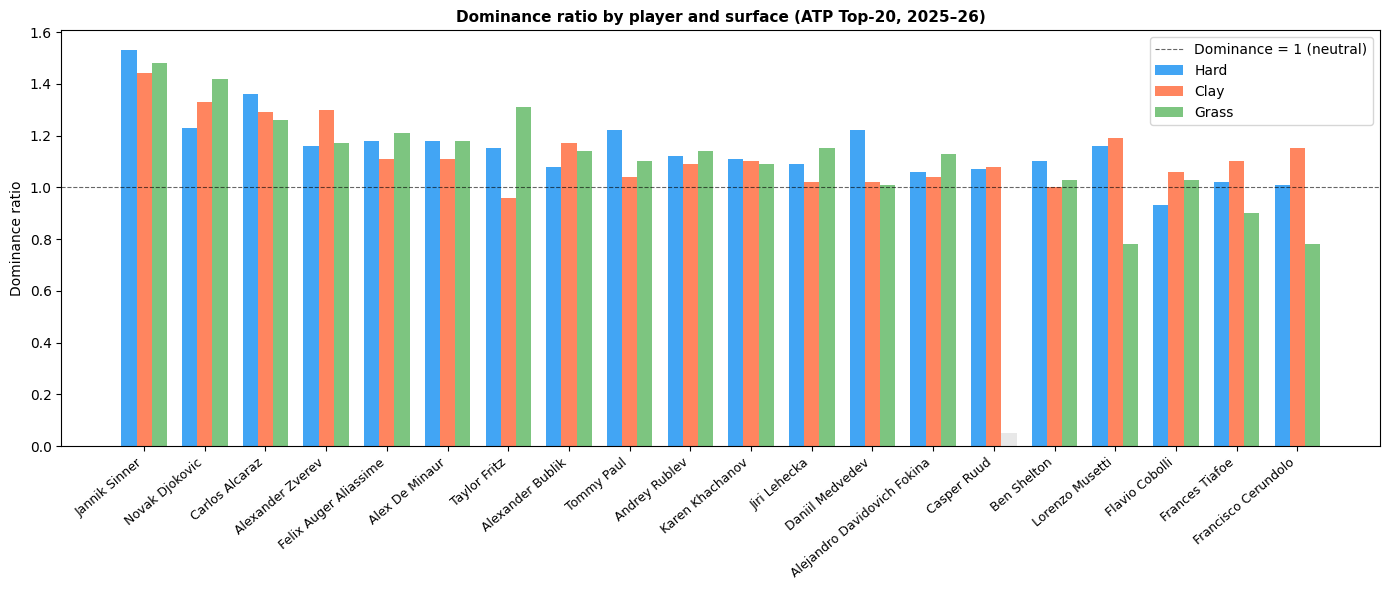

In [ ]:
players_ordered = dr_pivot[surfaces].mean(axis=1).sort_values(ascending=False).index
dr_plot = dr_pivot.loc[players_ordered, surfaces]

x = np.arange(len(players_ordered))
width = 0.25
colors = {"Hard": "#2196F3", "Clay": "#FF7043", "Grass": "#66BB6A"}

fig, ax = plt.subplots(figsize=(14, 6))

for i, surface in enumerate(surfaces):
    vals = dr_plot[surface].values
    bars = ax.bar(x + i * width, vals, width, label=surface,
                  color=colors[surface], alpha=0.85)

    # Grey out NaN bars visually
    for j, v in enumerate(vals):
        if np.isnan(v):
            ax.bar(x[j] + i * width, 0.05, width, color="lightgrey", alpha=0.5)

ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--", alpha=0.6, label="Dominance = 1 (neutral)")
ax.set_xticks(x + width)
ax.set_xticklabels(players_ordered, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Dominance ratio")
ax.set_title("Dominance ratio by player and surface (ATP Top-20, 2025–26)",
             fontsize=11, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR,"q2_dominance_ratio.png"), dpi=150, bbox_inches="tight")
plt.show()

### Note 
For consistency comparisons, we restrict the analysis to players with match data on all three surfaces, since zero values for grass reflect lack of participation rather than poor performance.

In [ ]:
# Standard deviation of match_pct across surfaces (ignoring NaN)
consistency = (
    stats_surfaces
    .groupby("player")["match_pct"]
    .agg(
        win_rate_std="std",
        surfaces_played="count"
    )
    .query("surfaces_played == 3")
    .sort_values("win_rate_std")
    .reset_index()
)

print("Surface consistency ranking (lower std = more consistent across surfaces):")
print(consistency.to_string(index=False))

Surface consistency ranking (lower std = more consistent across surfaces):
                     player  win_rate_std  surfaces_played
             Novak Djokovic      0.577350                3
              Jannik Sinner      2.000000                3
             Carlos Alcaraz      3.000000                3
                Ben Shelton      4.163332                3
              Andrey Rublev      5.291503                3
             Alex De Minaur      5.507571                3
             Flavio Cobolli      7.000000                3
           Alexander Zverev      7.371115                3
               Jiri Lehecka      7.549834                3
           Alexander Bublik      9.237604                3
            Karen Khachanov     10.148892                3
Alejandro Davidovich Fokina     10.503968                3
            Daniil Medvedev     11.532563                3
      Felix Auger Aliassime     12.055428                3
             Frances Tiafoe     15.88500

### Findings

- The top tier is clearly split into **all-surface elites** and **surface-tilted performers**. **Carlos Alcaraz, Jannik Sinner, and Novak Djokovic** remain high on all three surfaces (roughly 82-95% win rate), indicating broad adaptability rather than one-surface dependence.
- The strongest clay specialists in this sample are visible in both metrics: players like **Alcaraz** and **Djokovic** combine very high clay win rates with clay dominance ratios comfortably above 1.0. This suggests their clay success is backed by point-level control, not only close-match variance.
- Grass shows the largest dispersion across players. Some players post very high grass outcomes (for example **Alcaraz** and **Sinner**), while others are at the bottom end of the distribution.
- **Taylor Fritz** and **Tommy Paul** are clear examples of strong surface sensitivity. Fritz drops sharply on clay but is much stronger on grass, while Paul is very strong on clay but drops heavily on grass. Because this pattern appears in both **win rate** and **dominance ratio**, it looks like a genuine surface-fit effect rather than random short-term fluctuation.
- In this project interpretation, **Lorenzo Musetti** and **Francisco Cerundolo** are treated as not having meaningful grass participation in the scraped period; therefore they appear at **0% on grass** and this should not be interpreted as a direct quality ranking against players with full grass samples.
- The **dominance ratio** chart broadly confirms the win-rate heatmap: where a player has higher win rate on a surface, their dominance ratio is usually also higher there. This cross-metric alignment strengthens the interpretation that differences are structural (serve/return balance), not random noise.
- There are important exceptions worth noting. A player can be competitive in win rate while showing only moderate dominance ratio (or vice versa), which typically points to match-context effects (sample size, close-match distribution, opponent mix) rather than a pure quality gap.
- **Casper Ruud** has missing grass values (no grass matches in the scraped period), so his cross-surface consistency cannot be interpreted symmetrically with players who have data on all three surfaces. Comparisons of consistency should therefore prioritise complete three-surface profiles.

## Q3 — Which player characteristics are associated with winning matches?

We join match results with per-surface stats and player profile data (age, rank)
to compare the characteristics of winners vs losers at the point of each match.

Steps:
1. Join matches with stats on (player, surface) for both winner and loser
2. Join player age from the players table
3. Compare key stats between winners and losers
4. Visualise distributions with box plots and a correlation heatmap

Note on missing values:
Winner–loser comparisons are computed only for matches where both players have surface‑specific statistics available. As a result, metrics such as tiebreak win percentage are based on smaller subsets of matches and should be interpreted as conditional effects, rather than global predictors across all matches.

In [ ]:
# We only join surface-specific stats (not "Overall last 52")
surfaces = ["Hard", "Clay", "Grass"]
stats_for_join = stats[stats["surface"].isin(surfaces)].copy()

# Columns we want to carry into the match rows
stat_cols = [
    "ace_rate_pct",
    "first_serve_in_pct",
    "first_serve_points_won_pct",
    "second_serve_points_won_pct",
    "service_games_held_pct",
    "return_games_won_pct",
    "return_points_won_pct",
    "dominance_ratio",
    "tiebreak_pct",
]

stats_slim = stats_for_join[["player", "surface"] + stat_cols].copy()

: 

In [ ]:
# --- winner stats ---
winner_stats = (
    stats_slim
    .rename(columns={c: f"w_{c}" for c in stat_cols})
    .rename(columns={"player": "winner", "surface": "surface"})
)

# --- loser stats ---
loser_stats = (
    stats_slim
    .rename(columns={c: f"l_{c}" for c in stat_cols})
    .rename(columns={"player": "loser", "surface": "surface"})
)

# --- age from players table ---
# Normalise name format just in case of whitespace issues
players["name"] = players["name"].str.strip()

winner_age = players[["name", "age"]].rename(columns={"name": "winner", "age": "winner_age"})
loser_age  = players[["name", "age"]].rename(columns={"name": "loser",  "age": "loser_age"})

# --- build enriched matches ---
enriched = (
    matches
    .merge(winner_stats, on=["winner", "surface"], how="left")
    .merge(loser_stats,  on=["loser",  "surface"], how="left")
    .merge(winner_age,   on="winner",              how="left")
    .merge(loser_age,    on="loser",               how="left")
)

print(f"Enriched matches shape: {enriched.shape}")
print(f"Winner stats coverage : {enriched['w_dominance_ratio'].notna().sum()} / {len(enriched)}")
print(f"Loser stats coverage  : {enriched['l_dominance_ratio'].notna().sum()} / {len(enriched)}")
print(f"Winner age coverage   : {enriched['winner_age'].notna().sum()} / {len(enriched)}")

In [ ]:
# Delta = winner stat − loser stat for each metric
# A positive delta means the winner was better on that characteristic
delta_cols = {}
for col in stat_cols:
    delta_name = f"delta_{col}"
    enriched[delta_name] = enriched[f"w_{col}"] - enriched[f"l_{col}"]
    delta_cols[col] = delta_name

enriched["delta_rank"] = enriched["loser_rank_at_match"] - enriched["winner_rank_at_match"]
enriched["delta_age"]  = enriched["winner_age"] - enriched["loser_age"]

print("Delta columns added:")
for orig, delta in delta_cols.items():
    mean_val = enriched[delta].mean()
    print(f"  {delta:45s}  mean = {mean_val:+.3f}")

In [ ]:
plot_stats = [
    ("w_dominance_ratio",            "l_dominance_ratio",            "Dominance ratio"),
    ("w_first_serve_points_won_pct", "l_first_serve_points_won_pct", "1st serve pts won (%)"),
    ("w_return_points_won_pct",      "l_return_points_won_pct",      "Return pts won (%)"),
    ("w_service_games_held_pct",     "l_service_games_held_pct",     "Service games held (%)"),
    ("w_ace_rate_pct",               "l_ace_rate_pct",               "Ace rate (%)"),
    ("w_tiebreak_pct",               "l_tiebreak_pct",               "Tiebreak win (%)"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for ax, (w_col, l_col, title) in zip(axes, plot_stats):
    w_vals = enriched[w_col].dropna()
    l_vals = enriched[l_col].dropna()

    bp = ax.boxplot(
        [w_vals, l_vals],
        labels=["Winner", "Loser"],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=1.8),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )
    bp["boxes"][0].set_facecolor("#64B5F6")   # winner = blue
    bp["boxes"][1].set_facecolor("#EF9A9A")   # loser  = red

    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel("Value")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Winner vs Loser characteristics (ATP Top-20, 2025–26)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR,"q3_winner_vs_loser_boxplots.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Build a dataframe of all deltas and correlate with a binary outcome (1 = favourite won)
all_delta_cols = list(delta_cols.values()) + ["delta_rank", "delta_age"]

delta_df = enriched[all_delta_cols].copy()

# Readable labels for the plot
label_map = {
    "delta_ace_rate_pct":                  "Ace rate",
    "delta_first_serve_in_pct":            "1st serve in",
    "delta_first_serve_points_won_pct":    "1st serve pts won",
    "delta_second_serve_points_won_pct":   "2nd serve pts won",
    "delta_service_games_held_pct":        "Service games held",
    "delta_return_games_won_pct":          "Return games won",
    "delta_return_points_won_pct":         "Return pts won",
    "delta_dominance_ratio":               "Dominance ratio",
    "delta_tiebreak_pct":                  "Tiebreak win",
    "delta_rank":                          "Rank advantage",
    "delta_age":                           "Age difference",
}

corr = delta_df.rename(columns=label_map).corr()

fig, ax = plt.subplots(figsize=(11, 9))
cax = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(cax, ax=ax, shrink=0.8, label="Pearson r")

ticks = list(label_map.values())
ax.set_xticks(range(len(ticks)))
ax.set_xticklabels(ticks, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(len(ticks)))
ax.set_yticklabels(ticks, fontsize=8.5)

# Annotate cells
for i in range(len(ticks)):
    for j in range(len(ticks)):
        val = corr.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7, color="white" if abs(val) > 0.5 else "black")

ax.set_title("Correlation between winner–loser stat deltas (ATP Top-20, 2025–26)",
             fontsize=11, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR,"q3_delta_correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
summary = (
    pd.DataFrame({
        "characteristic": list(label_map.values()),
        "mean_delta":     [enriched[c].mean() for c in all_delta_cols],
        "matches_with_data": [enriched[c].notna().sum() for c in all_delta_cols],
    })
    .sort_values("mean_delta", ascending=False)
    .reset_index(drop=True)
)

print("Mean delta (winner − loser) per characteristic:")
print(summary.to_string(index=False))

## Findings — Player Characteristics Associated with Winning

### Overall performance differences (Winner vs. Loser)

- **Dominance ratio** shows a clear and consistent separation between winners and losers.  
  - Winners have systematically higher values, indicating that overall point superiority is one of the **strongest indicators of match success**.
  
- **First serve points won (%)** is noticeably higher for winners.  
  - This suggests that **effectiveness on first serve (not just getting it in)** is a key differentiator.

- **Return points won (%)** also shows a meaningful gap.  
  - Winners are not only strong on serve but also **consistently outperform opponents on return**, highlighting the importance of all-court performance.

- **Service games held (%)** is slightly higher for winners but with overlap.  
  - This indicates that while holding serve is important, it is **not sufficient alone** to explain winning.

- **Ace rate (%)** shows only minor differences.  
  - High ace rates are **not a decisive factor** among top players, suggesting that consistency and point construction matter more than pure power.

- **Tiebreak win (%)** distributions are highly variable with significant overlap.  
  - This metric appears **noisy and less reliable**, likely due to smaller sample sizes and situational dependence.

---

### Insights from winner–loser deltas

- Positive deltas (winner − loser) are observed across most key metrics, confirming that winners are generally **better in multiple dimensions simultaneously**, rather than excelling in just one.

- The strongest average advantages appear in:
  - **First serve points won**
  - **Return performance**
  - **Dominance ratio**

---

### Correlation analysis of performance gaps

- **Return games won (%) and return points won (%) are almost perfectly correlated (r ≈ 0.96)**  
  → These metrics capture essentially the same underlying concept of **return strength**.

- **Dominance ratio strongly correlates with return performance (r ≈ 0.68–0.69)**  
  → Indicates that **return ability is a major driver of overall match dominance**.

- **First serve points won (%) strongly correlates with service games held (%) (r ≈ 0.75)**  
  → Confirms that **winning points on first serve directly translates into holding serve**.

- **Ace rate is strongly correlated with first serve points won (r ≈ 0.77)**  
  → Suggests that aces contribute to serve effectiveness, but:
  - Given weak separation in boxplots, this effect is **not sufficient alone to explain match outcomes**.

- **Ace rate is negatively correlated with return metrics (≈ -0.5)**  
  → Players who rely more on serve dominance tend to be **weaker on return**, indicating a trade-off in play styles.

- **Second serve points won (%) correlates moderately with dominance ratio (r ≈ 0.52)**  
  → Highlights the importance of **consistency under pressure**, especially when the first serve fails.

---

### Role of contextual factors

- **Rank advantage shows moderate positive correlation with dominance ratio (r ≈ 0.43)**  
  → Higher-ranked players tend to dominate more, but rank alone does not fully explain match outcomes.

- **Age difference has weak correlations with most performance metrics**  
  → Suggests that within the ATP Top-20, **age is not a decisive factor** for match success.

---

### Key takeaway

- Winning at the top level is driven by a **combination of serve efficiency and return strength**, rather than isolated metrics.
- In particular:
  - **Return performance + dominance ratio** are the strongest overall indicators
  - **First serve effectiveness** is more important than raw serving power (aces)
- Success is therefore best explained by **balanced, all-around performance**, rather than specialization.